In [ ]:
# ML-Based Cyber Hygiene Project
# Module 1: Phishing Website Detection
# Goal: Predict whether a website URL is Safe or Phishing

In [ ]:
!unzip dataset_full.csv.zip

Archive:  dataset_full.csv.zip
  inflating: dataset_full.csv        


In [ ]:
!unzip dataset.zip -d phishing_data


unzip:  cannot find or open dataset.zip, dataset.zip.zip or dataset.zip.ZIP.


In [ ]:
import pandas as pd

df = pd.read_csv("dataset_full.csv")
df.head()

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


In [ ]:
df.shape

(88647, 112)

In [ ]:
df.columns


Index(['qty_dot_url', 'qty_hyphen_url', 'qty_underline_url', 'qty_slash_url',
       'qty_questionmark_url', 'qty_equal_url', 'qty_at_url', 'qty_and_url',
       'qty_exclamation_url', 'qty_space_url',
       ...
       'qty_ip_resolved', 'qty_nameservers', 'qty_mx_servers', 'ttl_hostname',
       'tls_ssl_certificate', 'qty_redirects', 'url_google_index',
       'domain_google_index', 'url_shortened', 'phishing'],
      dtype='object', length=112)

In [ ]:
df['phishing'].value_counts()

,count
phishing,
0,58000
1,30647


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.dtypes


,0
qty_dot_url,int64
qty_hyphen_url,int64
qty_underline_url,int64
qty_slash_url,int64
qty_questionmark_url,int64
...,...
qty_redirects,int64
url_google_index,int64
domain_google_index,int64
url_shortened,int64


In [ ]:
X = df.drop('phishing', axis=1)
y = df['phishing']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9314156796390299


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10908   692]
 [  524  5606]]


In [ ]:
#Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.9551043429216018
[[11141   459]
 [  337  5793]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     11600
           1       0.93      0.95      0.94      6130

    accuracy                           0.96     17730
   macro avg       0.95      0.95      0.95     17730
weighted avg       0.96      0.96      0.96     17730



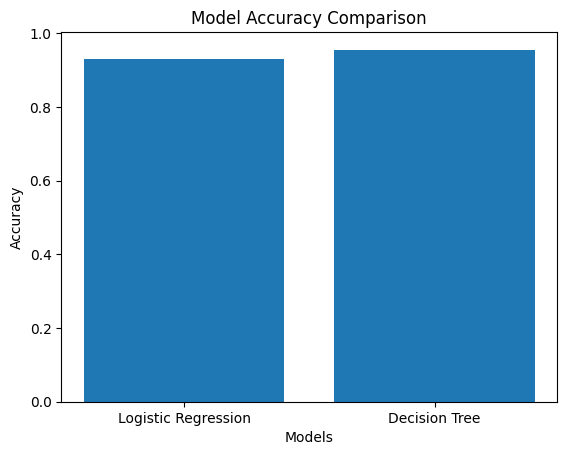

In [3]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree"]
accuracy = [0.93, 0.955]   # use your actual values

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()